In [2]:
import rastereasy

With `rastereasy`, you can plot spectral bands associated with selected pixels by a simple click. You can also extract in a list of numpy arrays the associated values.

# Important for google colab

To use the interactive plotting features in Google Colab, a special two-step setup is required. Follow these steps in the exact order. Separating the commands into different cells and restarting the session is **essential**.

### Step 1: Install Libraries

Run the following cell to install `rastereasy` and the necessary dependencies for interactive widgets.

```
!pip install rastereasy ipympl
from google.colab import output
output.enable_custom_widget_manager()
```

### Step 2: Restart the Runtime

After the installation is complete, you **must** restart the runtime.

Go to the menu: ``Runtime > Restart runtime`` (or use the shortcut `Ctrl+M`).

### Step 3: Run Your Code

After restarting, you can now enable the interactive mode and use the library in a **new cell**.

```
%matplotlib widget
import rastereasy
```


# 1) Open an image

In [3]:
name_im='./data/demo/sentinel.tif'
names = {"NIR":8,"G":3,"CO" : 1,"SWIR2":11,"B": 2,"R":4,"RE1":5,"RE2":6,"RE3":7,"WA":9,"SWIR1":10,"SWIR3":12}
image_names=rastereasy.open(name_im,names=names)

# 2) Plot spectra by clicking on pixels

In [4]:
help(image_names.plot_spectra)

Help on method plot_spectra in module rastereasy:

plot_spectra(
    bands=None,
    fig_size=(15, 5),
    percentile=2,
    title='',
    title_im='Original image (click outside to stop)',
    title_spectra='Spectra',
    xlabel='Bands',
    ylabel='Value',
    zoom=None,
    pixel=None
) method of rastereasy.Geoimage instance
    Interactive tool to explore and plot spectral values from user-selected pixels.

    This method displays the image and allows the user to click on pixels to see
    their spectral values across all bands plotted as a line graph. Multiple pixels
    can be selected to compare different spectral signatures.

    Parameters
    ----------
    bands : list of str, optional
        List of three band identifiers to use for the background image display.
        If None, uses the first three bands in the image.
        Default is None.

    fig_size : tuple, optional
        Size of the figure in inches as (width, height).
        Default is (15, 5).

    percenti

## Plot spectra with the three first bands in color composition


You can click on the `Finish` button or outside the image to stop the visualization.

Label(value='Click on the image to retrieve spectra.')

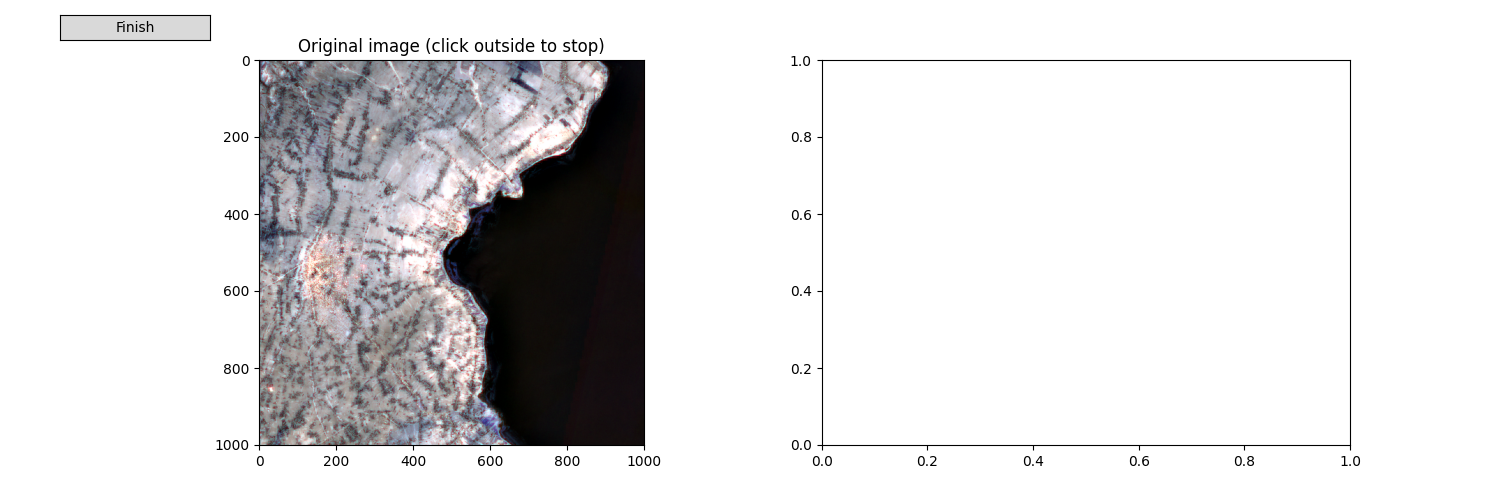

([], [], [])

In [5]:
# If google colab, do not forget to put `%matplotlib widget` before importing rastereasy
image_names.plot_spectra()
# -> This will plot an image where you can click to visualize spectre

## Plot spectra with selected bands for color composition


Label(value='Click on the image to retrieve spectra.')

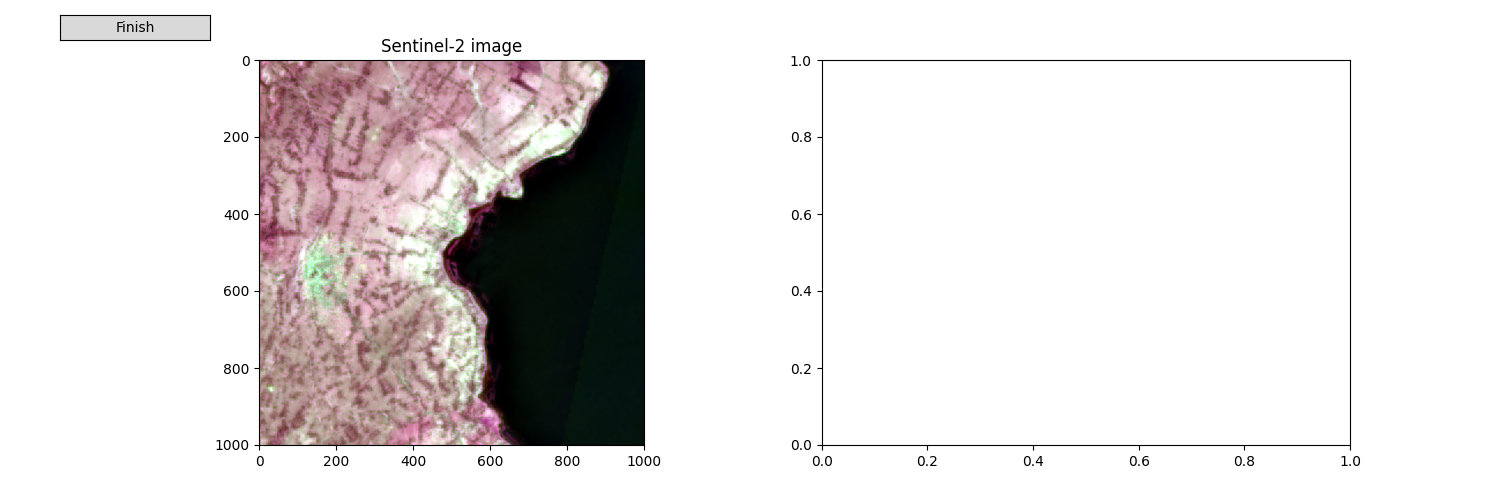

([], [], [])

In [6]:
image=rastereasy.open(name_im)
# If google colab, do not forget to put `%matplotlib widget` before importing rastereasy
image.plot_spectra(['5','1','3'],title_im='Sentinel-2 image',title_spectra='associated spectra',xlabel='given bands',ylabel='spectral values')

# -> This will plot an image where you can click to visualize spectre


# 3) Get spectral values of some pixels selected by a simple click

To this end, you need to put in some variables the outputs

Label(value='Click on the image to retrieve spectra.')

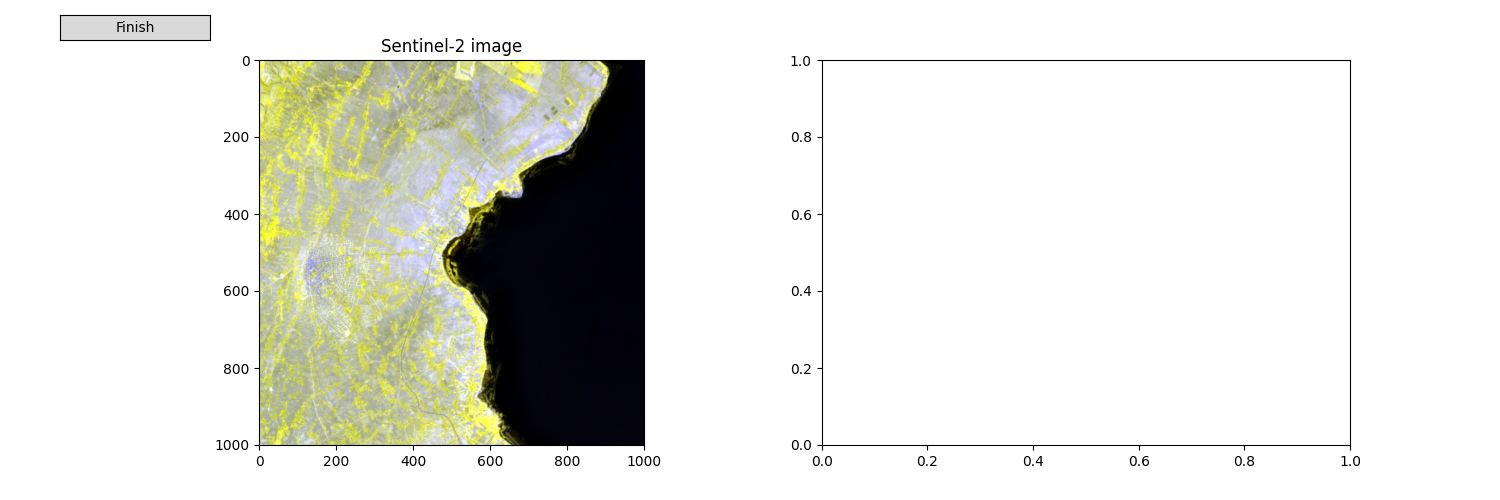

In [7]:
# If google colab, do not forget to put `%matplotlib widget` before importing rastereasy
series, pixels_i,pixels_j = image.plot_spectra(['8','9','2'],title_im='Sentinel-2 image',title_spectra='associated spectra',xlabel='given bands',ylabel='spectral values')


In [8]:
print('collect %d spectra'%len(series))
for i in range(len(series)):
    print('*[%.3d] pixel i = '%(i+1), pixels_i[i], 'pixel j = ', pixels_j[i], 'spectral values = ',series[i])

collect 19 spectra
*[001] pixel i =  674 pixel j =  305 spectral values =  [ 785 1006 1342 1714 2060 2310 2461 2640 2727 2879 3517 3212]
*[002] pixel i =  627 pixel j =  505 spectral values =  [1242 1434 1734 2126 2451 2575 2710 2670 2798 2786 3617 3425]
*[003] pixel i =  500 pixel j =  708 spectral values =  [251 254 485 338 361 243 259 229 245 226 173 137]
*[004] pixel i =  313 pixel j =  557 spectral values =  [ 889  958 1250 1490 1843 2195 2388 2602 2730 2703 3006 2647]
*[005] pixel i =  225 pixel j =  248 spectral values =  [ 673 1002 1392 1862 2108 2338 2443 2452 2723 2761 3382 3112]
*[006] pixel i =  178 pixel j =  316 spectral values =  [ 848  974 1230 1630 1968 2119 2289 2331 2454 2458 3349 3211]
*[007] pixel i =  167 pixel j =  586 spectral values =  [ 736 1200 1484 1798 1956 2205 2484 2464 2612 2504 3095 2886]
*[008] pixel i =  160 pixel j =  729 spectral values =  [1073 1254 1562 2092 2309 2408 2495 2524 2617 2666 3553 3486]
*[009] pixel i =  321 pixel j =  890 spectral val

Label(value='Click on the image to retrieve spectra.')

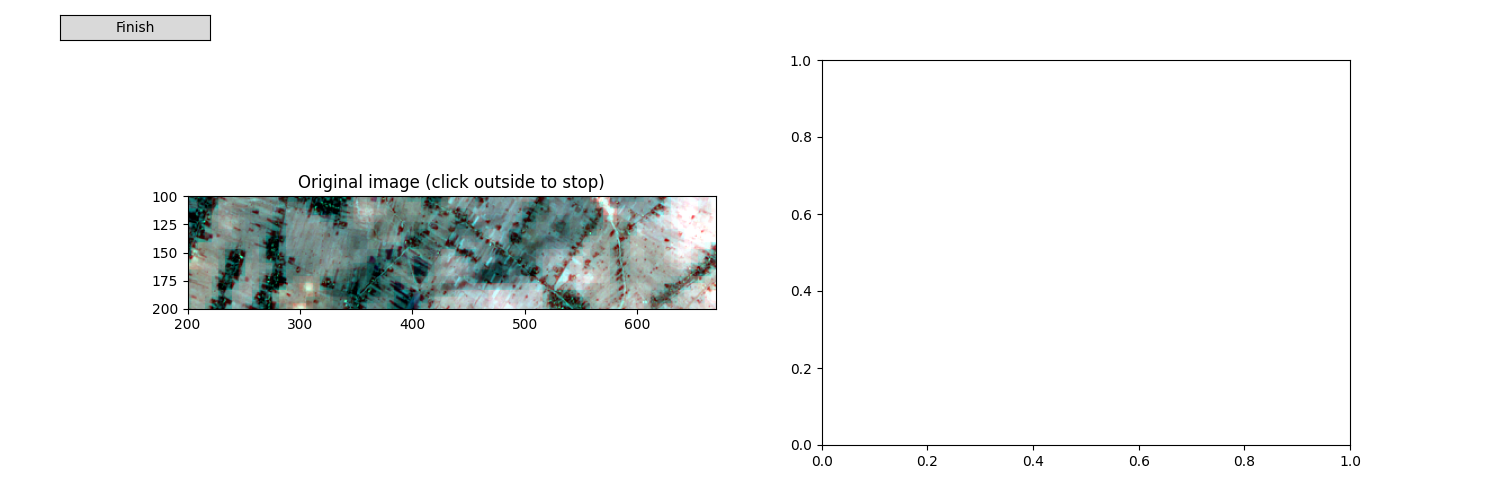

In [9]:
# 4) Get spectral values of some pixels by zooming the image

series, pixels_i,pixels_j = image_names.plot_spectra(zoom=((100,200),(200,670)))
#series, pixels_i,pixels_j = image_names.plot_spectra()


In [10]:
print('collect %d spectra'%len(series))
for i in range(len(series)):
    print('*[%.3d] pixel i = '%(i+1), pixels_i[i], 'pixel j = ', pixels_j[i], 'spectral values = ',series[i])

collect 6 spectra
*[001] pixel i =  152 pixel j =  308 spectral values =  [ 756  926 1228 1666 1979 2073 2181 2208 2308 2312 3191 3068]
*[002] pixel i =  157 pixel j =  422 spectral values =  [ 768 1042 1376 1786 2010 2134 2206 2224 2342 2498 3224 3059]
*[003] pixel i =  131 pixel j =  518 spectral values =  [ 725  946 1294 1738 2000 2082 2169 2136 2254 2277 3108 3062]
*[004] pixel i =  118 pixel j =  474 spectral values =  [ 741  902 1254 1730 2071 2138 2206 2148 2312 2251 3055 2976]
*[005] pixel i =  125 pixel j =  307 spectral values =  [ 809 1021 1362 1818 2069 2193 2359 2382 2504 2491 3454 3323]
*[006] pixel i =  138 pixel j =  258 spectral values =  [ 768  939 1292 1710 2025 2084 2219 2216 2345 2411 3271 3190]
